In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from collections import Counter
from sklearn.utils import resample
from sklearn.utils import check_random_state
from scipy.stats import gaussian_kde, linregress, pearsonr, percentileofscore
from scipy import stats
from itertools import islice
import pickle
import warnings
warnings.filterwarnings('ignore')

## Functions

In [62]:
def plot_pred_vs_true_density(df_final):
  [y_true_all, y_pred_all] = df_final['y_labels'], df_final['y_pred']

  xy = np.vstack([y_true_all, y_pred_all]) 
  density = gaussian_kde(xy)(xy)      

  sizes = 100 * (density / density.max()) 

  plt.figure(figsize=(5, 2.8))

  plt.subplot(1,2,1)
  scatter = plt.scatter(y_true_all, y_pred_all, c=density, s=sizes, cmap='viridis', alpha=0.6)
  #plt.plot([min(y_true_all), max(y_true_all)], [min(y_true_all), max(y_true_all)], 'k--')
  slope, intercept, r_value, p_value, std_err = linregress(df_final['y_labels'], df_final['y_pred'])
  plt.plot(df_final['y_labels'], intercept + slope * df_final['y_labels'], color='black')
  plt.xlabel('Age')
  plt.ylabel('Age predicted')

  r_value1 = np.abs(r_value)
  d_cohen = (2 * r_value1) / np.sqrt(1 - r_value1**2)

  plt.title( f'd-cohen={d_cohen:.2f} \nr={r_value:.2f} p={p_value:.2e}')


  [y_true_all, y_pred_all] = df_final['y_labels'], df_final['y_pred_corrected']

  xy = np.vstack([y_true_all, y_pred_all]) 
  density = gaussian_kde(xy)(xy)      
  sizes = 100 * (density / density.max()) 

  plt.subplot(1,2,2)
  scatter = plt.scatter(y_true_all, y_pred_all, c=density, s=sizes, cmap='viridis', alpha=0.6)
  plt.plot([min(y_true_all), max(y_true_all)], [min(y_true_all), max(y_true_all)], 'k--')
  slope, intercept, r_value, p_value, std_err = linregress(df_final['y_labels'], df_final['y_pred_corrected'])
  plt.plot(df_final['y_labels'], intercept + slope * df_final['y_labels'], color='black')
  plt.xlabel('Age')
  plt.ylabel('Age predicted')

  r_value1 = np.abs(r_value)
  d_cohen = (2 * r_value1) / np.sqrt(1 - r_value1**2)

  plt.title( f'd-cohen={d_cohen:.2f} \nr={r_value:.2f} p={p_value:.2e}')

  plt.tight_layout()
  return None

In [63]:
def plot_signed_perm_importance(df_final, perm_importance_avg, best_features,
                xlim=None, ylim=None):

  df_final['GAP_bin'] = np.where(df_final['GAP_corrected'] <= 0, 0, 1)

  results = []
  for col in best_features:
    corr, pval = pearsonr(df_final['Age'], df_final[col])
    direction = 'Positive' if corr > 0 else 'Negative'
    results.append({'Variable': col, 'Correlation': corr,
            'Direction': direction, 'p-value': pval})

  dir_df = pd.DataFrame(results)

  combined_df = pd.DataFrame({
    'Importance': perm_importance_avg
  }).reset_index().rename(columns={'index': 'Variable'})

  combined_df = combined_df.merge(dir_df, on='Variable', how='inner')

  combined_df['SignedImportance'] = np.where(
    combined_df['Direction'] == 'Positive',
    combined_df['Importance'],
    -combined_df['Importance']
  )

  combined_df = combined_df.reindex(
    combined_df['Importance'].abs().sort_values(ascending=True).index
  )

  plt.figure(figsize=(4, 5))
  for _, row in combined_df.iterrows():
    plt.barh(
      row['Variable'],
      row['SignedImportance'],
      color='tomato' if row['SignedImportance'] > 0 else 'green',
      alpha=0.4 if row['p-value'] > 0.05 else 1.0
    )

  plt.axvline(0, color='black', linewidth=0.8)
  plt.xlabel('Importance')
  plt.ylabel('Features')

  if xlim is not None:
    plt.xlim(xlim)
  if ylim is not None:
    plt.ylim(ylim)

  plt.tight_layout()
  plt.show()

  return combined_df

In [64]:
def permtest(x, y, statistic="mean", max_samples=5000, random_state=42):
  """
  Conducts a permutation test between two independent samples.
  Parameters
  ----------
  x : ndarray
    First set of datapoints.
  y : ndarray
    Second set of datapoints.
  statistic : str or callable, optional
    Function that takes in samples x and y and reports
    statistic of interest. By default, "mean" reports
    the difference of sample means. List of default
    options are ("mean", "median").
  max_samples : int, optional.
    Maximum number of label permutations to try.
  random_state : np.random.RandomState, int, or None.
    If specified, used to seed the random number generator to shuffle the ordering of the datapoints.
  """

  # Initialize random state and function of interest
  rs = check_random_state(random_state)
  stat_func = _get_stat_func(statistic)

  # Concatenate samples
  xy = np.concatenate((x, y))
  n_x = x.size

  # Observed statistic
  observed_stat = stat_func(x, y)

  # Set the number of permutations to compute
  n_perms = max(max_samples, 100000) # Limit the number of permutations to a manageable number (e.g., 10000)

  # Allocate space for computed statistics
  shuffled_stats = np.empty(n_perms)

  # Print coverage
  print(f"Computing permutations...")

  # Sampling random permutations
  for i in range(n_perms):
    rs.shuffle(xy)
    x_ = xy[:n_x]
    y_ = xy[n_x:]
    shuffled_stats[i] = stat_func(x_, y_)

  # Compute a two-sided p-value. We take the smallest
  # percentile and then multiply by two.
  pval = 2 * min(
    percentileofscore(shuffled_stats, observed_stat, kind="rank") / 100,
    1 - percentileofscore(shuffled_stats, observed_stat, kind="rank") / 100
  )

  return pval

def _get_stat_func(name_or_func):
  """
  Instantiates functions that compute default statistics of interest.
  """
  # If specified function is callable
  if not isinstance(name_or_func, str):
    if callable(name_or_func):
      return name_or_func
    else:
      raise ValueError(
        "`statistic` should be a string like ('mean', 'median')"
        " or a function that takes in samples x, y and returns"
        " the statistic of interest."
      )

  # Default functions
  if name_or_func == "mean":
    return lambda x, y: np.mean(x) - np.mean(y)
  elif name_or_func == "median":
    return lambda x, y: np.median(x) - np.median(y)
  else:
    raise ValueError("Did not recognize statistic.")

In [65]:
def remove_outliers_iqr(data):
  """
  Removes outliers from an array based on the IQR criterion.
  
  Parameters:
  - data: NumPy array (or list).
  
  Returns:
  - NumPy array without outliers.
  """
  # Convert to a NumPy array if it isn't already
  data = np.array(data)

  # Calculate Q1, Q3 and IQR
  Q1 = np.percentile(data, 25)
  Q3 = np.percentile(data, 75)
  IQR = Q3 - Q1

  # Define the lower and upper bounds

  ir_mult = 1.5
  lower_bound = Q1 - ir_mult * IQR
  upper_bound = Q3 + ir_mult * IQR

  # Filter the data within the bounds
  filtered_data = data[(data >= lower_bound) & (data <= upper_bound)]
  
  return filtered_data


def cliff_delta(group1, group2):
  # Remove outliers from both groups using the remove_outliers_iqr function

  group1_ = remove_outliers_iqr(group1)
  group2_ = remove_outliers_iqr(group2)
  
  sub_sample_size = np.min([int(group1_.shape[0]*0.9), int(group2_.shape[0]*0.9)])

  delta_l = []
  for i in range(10):
    
    group1 = resample(group1_, n_samples=sub_sample_size, replace=False, random_state=i)
    group2 = resample(group2_, n_samples=sub_sample_size, replace=False, random_state=i)
  
    # Expand both matrices to compare each value with all other values
    group1_exp = group1[:, np.newaxis] # Expands group1 to a column matrix
    group2_exp = group2[np.newaxis, :]  # Expands group2 to a row matrix
  
    # Vectorized comparisons
    greater = np.sum(group1_exp > group2_exp)
    less = np.sum(group1_exp < group2_exp)
  
    # Calculate Cliff's Delta
    n1, n2 = len(group1), len(group2)
    delta = (greater - less) / (n1 * n2)

  delta_l.append(delta)

  print('N', n1+n2, n1, n2)

  return (np.round(np.mean(delta_l), 4), np.round(np.std(delta_l)*2.58,100))

In [66]:
from IPython.display import display
def violin_mannwhitney_cliff(df_final, group_col):
  order = [0, 1]

  groups = df_final[group_col].dropna().unique()
  mann_whitney_results = []

  for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
      region1_data = df_final[df_final[group_col] == groups[i]]['GAP_corrected']
      region2_data = df_final[df_final[group_col] == groups[j]]['GAP_corrected']

      stat, p_value = stats.mannwhitneyu(region1_data, region2_data, alternative='two-sided')

      cliff_d, cliff_ci = cliff_delta(np.array(region1_data), np.array(region2_data))
      print("cliff delta", cliff_d, cliff_ci)

      p_value_ = permtest(region1_data, region2_data)
      mann_whitney_results.append((groups[i], groups[j], cliff_d, cliff_ci, p_value_*len(groups), p_value*len(groups)))

  results_list = []
  for result in mann_whitney_results:
    result_dict = {
      "Group1": result[0],
      "Group2": result[1],
      "cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L)": np.abs(result[2]),
      "CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L)": np.abs(result[3]),
      "p-value 100000 perm": np.abs(result[4]),
      "p-value mann whitney": np.abs(result[5]),
    }
    results_list.append(result_dict)

  results_df = pd.DataFrame(results_list)
  display(results_df)

  custom_palette = ['#706513', '#520120', '#B57114']

  plt.figure(figsize=(4, 4))
  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',
          palette=custom_palette)
  plt.axhline(0, color='gray', linestyle='--', linewidth=1) # Line at zero

  plt.xlabel(group_col)
  plt.ylabel('BBAG corrected')
  plt.ylim([-15, 25])

  #plt.show()

  return results_df

## All vars results

### all subjects

In [67]:
df_final = pd.read_parquet('../../Results/all-vars_all-subjects-Incidence.parquet')

#### papers stats

In [68]:
data_for_stats = df_final.copy()
data_for_stats['Education'] = data_for_stats['Education'].replace({0:'None/Elementary school', 
                                  1:'None/Elementary school', 
                                  2:'Middle/High school', 
                                  3:'Middle/High school', 
                                  4:'College'})


data_for_stats['CountriesUnique'] = data_for_stats['Countries'].replace({'Peru (urban)':'Peru', 
                                     'Peru (rural)':'Peru', 
                                     'Mexico (rural)':'Mexico', 
                                     'Mexico (urban)':'Mexico'})


Counter(data_for_stats.dropna(subset=['Education']).Education)

Counter({'Middle/High school': 4225,
         'None/Elementary school': 3103,
         'College': 1016,
         1.9773489932885906: 47})

In [69]:
df = data_for_stats[['Sex_1F_2M', 'Age', 'Countries', 'Education']].copy()

# Avoid duplicates by spaces / variants
df['Countries'] = df['Countries'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()

# -------- Age mean (SD)
age_agg = df.groupby('Countries')['Age'].agg(['mean', 'std'])
age_stats = (age_agg['mean'].round(1).astype(str) +
       " (" + age_agg['std'].round(1).astype(str) + ")").rename('Age mean (SD)')

# -------- N (% Female)
sex_agg = df.groupby('Countries')['Sex_1F_2M'].agg(
  N='size',
  pct_female=lambda s: s.eq(1).mean() * 100
)
n_stats = (sex_agg['N'].astype(int).astype(str) +
      " (" + sex_agg['pct_female'].round(1).astype(str) + "%)").rename('N (% Female)')

# -------- Education % (Education is string)
edu = df[['Countries', 'Education']].copy()
edu['Education'] = edu['Education'].astype(str).str.strip()

# Exclude "1.9365..." value even if it comes as string
bad_val = "1.936546819438957"
edu = edu.loc[edu['Education'].notna() & (edu['Education'] != bad_val)]

counts = edu.groupby(['Countries', 'Education']).size()
pct = counts / counts.groupby(level=0).transform('sum') * 100

edu_stats = (pct.unstack('Education')
        .round(1)
        .astype(str)
        .add('%'))

# -------- Final merge
table = pd.concat([age_stats, n_stats, edu_stats], axis=1)
table

,Age mean (SD),N (% Female),1.9773489932885906,College,Middle/High school,None/Elementary school
Countries,,,,,,
Cuba,78.4 (6.3),1970 (66.4%),0.2%,17.3%,59.6%,22.8%
DR,79.0 (6.7),1170 (69.1%),0.7%,3.9%,26.0%,69.4%
Mexico (rural),76.6 (6.3),709 (62.6%),nan%,1.4%,15.9%,82.7%
Mexico (urban),76.8 (6.1),746 (66.5%),nan%,9.1%,33.8%,57.1%
Peru (rural),77.4 (6.7),420 (54.0%),1.7%,2.9%,56.4%,39.0%
Peru (urban),77.6 (7.0),889 (66.4%),0.7%,22.2%,68.1%,9.1%
Puerto Rico,79.5 (6.5),1238 (68.3%),0.4%,22.8%,57.1%,19.7%
Venezuela,76.0 (6.2),1249 (64.8%),1.4%,4.8%,66.6%,27.2%


#### Density plot

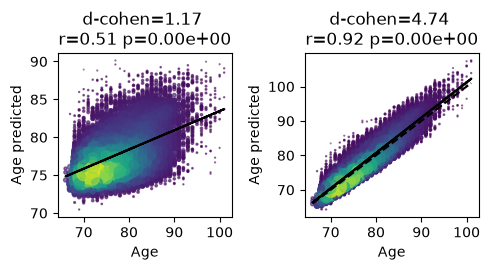

In [70]:
plot_pred_vs_true_density(df_final)

#### Features importance

In [71]:
pkl_path="../../SFS/best_features-all-vars_all-subjects-Incidence.pkl"

with open(pkl_path, "rb") as f:
    best_features = pickle.load(f)

In [72]:
perm_importance_avg = pd.read_parquet("../../Results/all-vars_all-subjects-perm_imp-Incidence.parquet")["perm_importance"]


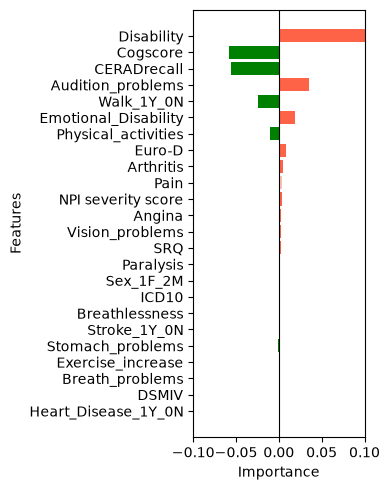

In [73]:
combined_df = plot_signed_perm_importance(df_final, 
                     perm_importance_avg, best_features, 
                     xlim=(-0.1, 0.1))#, ylim=(22.5, 35.5))


#### AnyDem comparision

N 2150 1075 1075
cliff delta -0.7938 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,0.0,1.0,0.7938,0.0,0.0,0.0


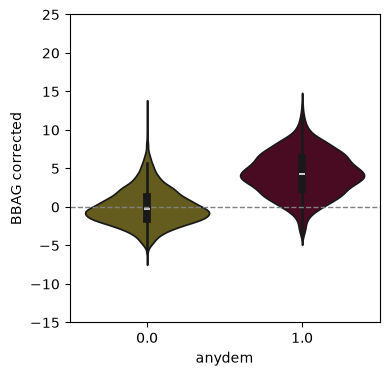

In [74]:
results_df = violin_mannwhitney_cliff(df_final, group_col="anydem")
plt.savefig("../../Figures/Model-A_permtest-anydem-Incidence.pdf", format="pdf", bbox_inches="tight", dpi=300)

#### Dsmcase comparision

N 1006 503 503
cliff delta -0.8161 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,0.0,1.0,0.8161,0.0,0.0,3.131796e-199


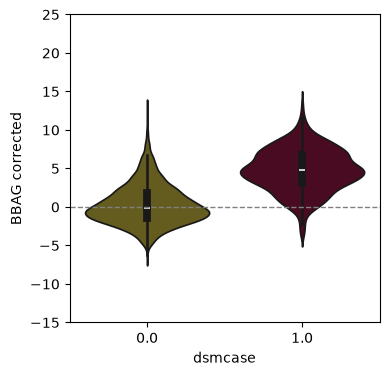

In [75]:
results_df = violin_mannwhitney_cliff(df_final, group_col="dsmcase")
plt.savefig("../../Figures/Model-A_permtest-dsmcase-Incidence.pdf", format="pdf", bbox_inches="tight", dpi=300)

#### Cogcase comparision

N 4130 2065 2065
cliff delta -0.7487 0.0
Computing permutations...
N 1222 611 611
cliff delta -0.4745 0.0
Computing permutations...
N 1222 611 611
cliff delta 0.3969 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,1.0,3.0,0.7487,0.0,0.0,0.000000e+00
1,1.0,2.0,0.4745,0.0,0.0,3.522638e-85
2,3.0,2.0,0.3969,0.0,0.0,1.460408e-56


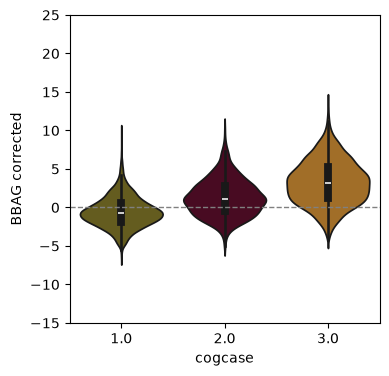

In [76]:
results_df = violin_mannwhitney_cliff(df_final, group_col="cogcase")
plt.savefig("../../Figures/Model-A_permtest-cogcase-Incidence.pdf", format="pdf", bbox_inches="tight", dpi=300)

## All wo-used-diag-vars

### all subjects

In [77]:
df_final = pd.read_parquet('../../Results/wo-used-diag-vars_all-subjects-Incidence.parquet')

#### Density plot

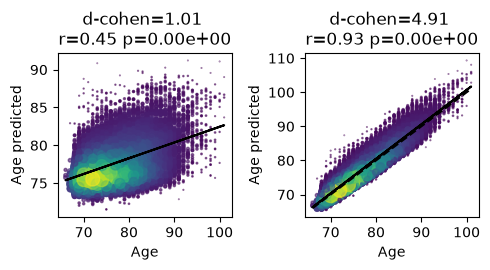

In [78]:
plot_pred_vs_true_density(df_final)

#### Features importance

In [79]:
import pickle
pkl_path="../../SFS/best_features-wo-used-diag-vars_all-subjects-Incidence.pkl"

with open(pkl_path, "rb") as f:
    best_features = pickle.load(f)

In [80]:
perm_importance_avg = pd.read_parquet("../../Results/wo-used-diag-vars_all-subjects-perm_imp-Incidence.parquet")["perm_importance"]


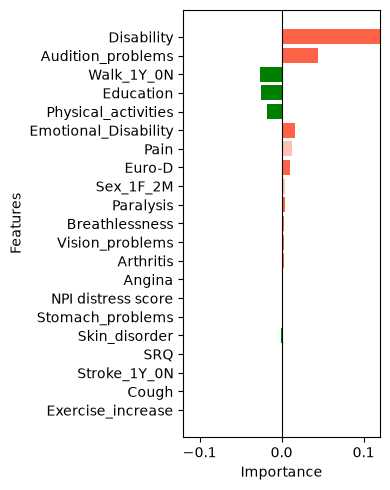

In [81]:
combined_df = plot_signed_perm_importance(df_final, 
                     perm_importance_avg, best_features,
                     xlim=(-0.12, 0.12))#, ylim=(8.5, 21.5))


#### AnyDem comparision

N 2154 1077 1077
cliff delta -0.5315 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,0.0,1.0,0.5315,0.0,0.0,7.811426e-164


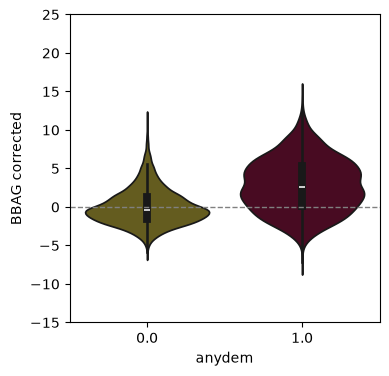

In [82]:
results_df = violin_mannwhitney_cliff(df_final, group_col="anydem")
plt.savefig("../../Figures/Model-B_permtest-anydem-Incidence.pdf", format="pdf", bbox_inches="tight", dpi=300)

#### Dsmcase comparision

N 1016 508 508
cliff delta -0.6578 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,0.0,1.0,0.6578,0.0,0.0,6.689387e-125


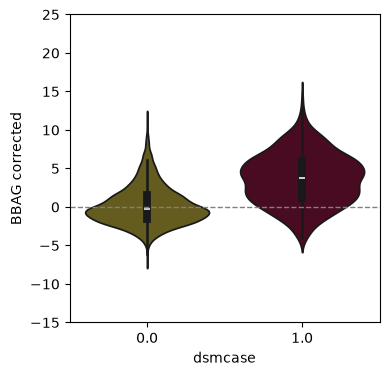

In [83]:
results_df = violin_mannwhitney_cliff(df_final, group_col="dsmcase")
plt.savefig("../../Figures/Model-B_permtest-dsmcase-Incidence.pdf", format="pdf", bbox_inches="tight", dpi=300)

#### Cogcase comparision

N 4138 2069 2069
cliff delta -0.4313 0.0
Computing permutations...
N 1206 603 603
cliff delta -0.1434 0.0
Computing permutations...
N 1206 603 603
cliff delta 0.3175 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,1.0,3.0,0.4313,0.0,0.0,8.436169e-170
1,1.0,2.0,0.1434,0.0,0.0,6.449080e-12
2,3.0,2.0,0.3175,0.0,0.0,1.047436e-22


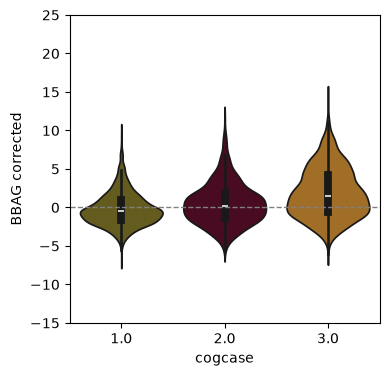

In [84]:
results_df = violin_mannwhitney_cliff(df_final, group_col="cogcase")
plt.savefig("../../Figures/Model-B_permtest-cogcase-Incidence.pdf", format="pdf", bbox_inches="tight", dpi=300)

## All wo-used-diag-vars-and-funct-vars 

### all subjects

In [85]:
df_final = pd.read_parquet('../../Results/wo-used-diag-vars-and-funct-vars_all-subjects-Incidence.parquet')

#### Density plot

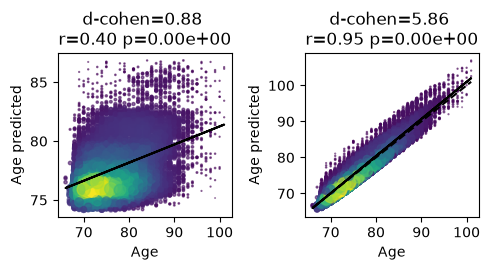

In [86]:
plot_pred_vs_true_density(df_final)


#### Features importance

In [87]:
import pickle
pkl_path="../../SFS/best_features-wo-used-diag-vars-and-funct-vars_all-subjects-Incidence.pkl"

with open(pkl_path, "rb") as f:
    best_features = pickle.load(f)

In [88]:
perm_importance_avg = pd.read_parquet("../../Results/wo-used-diag-vars-and-funct-vars_all-subjects-perm_imp-Incidence.parquet")["perm_importance"]


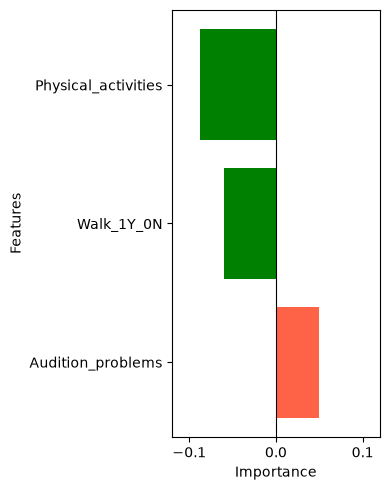

In [89]:
combined_df = plot_signed_perm_importance(df_final, 
                     perm_importance_avg, best_features, 
                     xlim=(-0.12, 0.12))#, ylim=(10.5, 23.5))


#### AnyDem comparision

N 2156 1078 1078
cliff delta -0.5029 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,0.0,1.0,0.5029,0.0,0.0,1.676084e-144


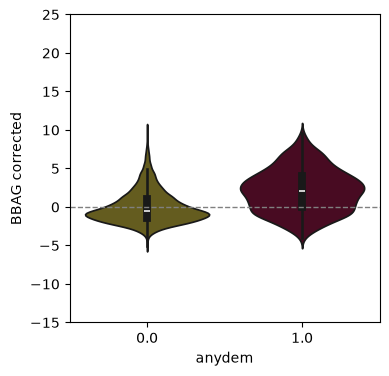

In [90]:
results_df = violin_mannwhitney_cliff(df_final, group_col="anydem")
plt.savefig("../../Figures/Model-C_permtest-anydem-Incidence.pdf", format="pdf", bbox_inches="tight", dpi=300)

#### Dsmcase comparision

N 1018 509 509
cliff delta -0.5576 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,0.0,1.0,0.5576,0.0,0.0,6.528073e-91


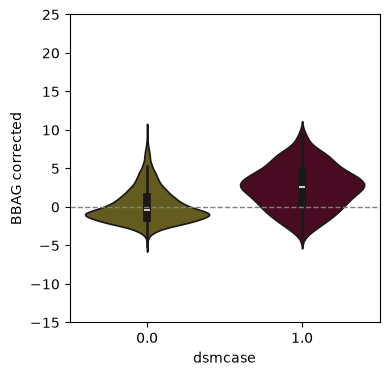

In [91]:
results_df = violin_mannwhitney_cliff(df_final, group_col="dsmcase")
plt.savefig("../../Figures/Model-C_permtest-dsmcase-Incidence.pdf", format="pdf", bbox_inches="tight", dpi=300)

#### Cogcase comparision

N 4140 2070 2070
cliff delta -0.4667 0.0
Computing permutations...
N 1198 599 599
cliff delta -0.2296 0.0
Computing permutations...
N 1198 599 599
cliff delta 0.2942 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,1.0,3.0,0.4667,0.0,0.0,2.824381e-182
1,1.0,2.0,0.2296,0.0,0.0,1.327345e-19
2,3.0,2.0,0.2942,0.0,0.0,2.399870e-17


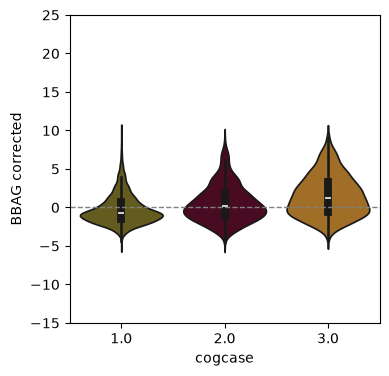

In [92]:
results_df = violin_mannwhitney_cliff(df_final, group_col="cogcase")
plt.savefig("../../Figures/Model-C_permtest-cogcase-Incidence.pdf", format="pdf", bbox_inches="tight", dpi=300)